In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd


data = pd.read_csv('/content/drive/MyDrive/Social_Network_Ads.csv')

data.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
X = data[['Age', 'EstimatedSalary']]
X


,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [ ]:
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
data.iloc[:,2:4]

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [ ]:
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
y=data["Purchased"]
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test, y_train, y_test

(     Age  EstimatedSalary
 3     27            57000
 18    46            28000
 202   39           134000
 250   44            39000
 274   57            26000
 ..   ...              ...
 71    24            27000
 106   26            35000
 270   43           133000
 348   39            77000
 102   32            86000
 
 [320 rows x 2 columns],
      Age  EstimatedSalary
 209   46            22000
 280   59            88000
 33    28            44000
 210   48            96000
 93    29            28000
 ..   ...              ...
 246   35            50000
 227   56           133000
 369   54            26000
 176   35            47000
 289   37            78000
 
 [80 rows x 2 columns],
 3      0
 18     1
 202    1
 250    0
 274    1
       ..
 71     0
 106    0
 270    0
 348    0
 102    0
 Name: Purchased, Length: 320, dtype: int64,
 209    0
 280    1
 33     0
 210    1
 93     0
       ..
 246    0
 227    1
 369    1
 176    0
 289    1
 Name: Purchased, Length: 80, dtyp

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

print(X_train_scaled.head())

        Age  EstimatedSalary
0 -1.066752        -0.386344
1  0.797535        -1.229939
2  0.110692         1.853544
3  0.601294        -0.909955
4  1.876859        -1.288118


In [ ]:
scaler.mean_

array([3.7871875e+01, 7.0281250e+04])

In [ ]:
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),   # Note: only transform, not fit_transform
    columns=X_test.columns
)

print(X_test_scaled.head())

        Age  EstimatedSalary
0  0.797535        -1.404475
1  2.073100         0.515429
2 -0.968632        -0.764507
3  0.993775         0.748145
4 -0.870512        -1.229939


In [ ]:
scaler.mean_

array([3.7871875e+01, 7.0281250e+04])

In [ ]:
import numpy as np
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


In [ ]:
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'scalled')

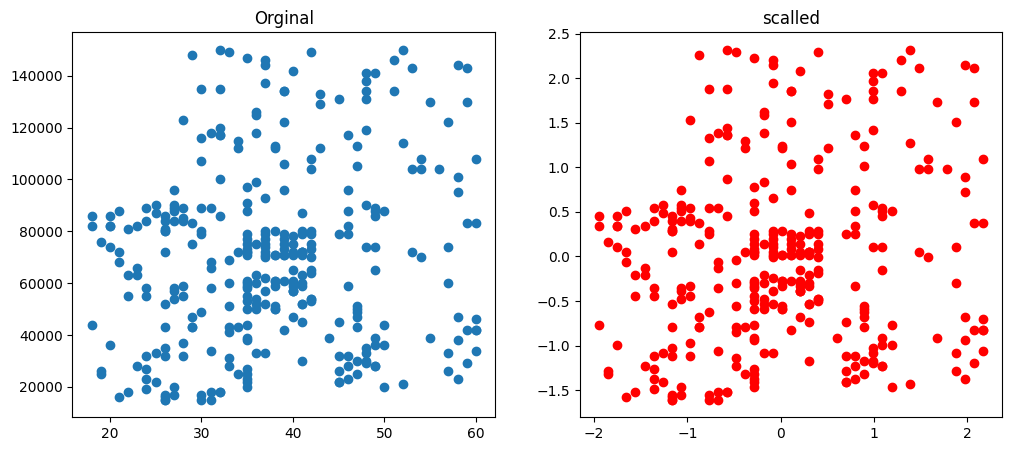

In [ ]:
fig,(fig1,fig2)=plt.subplots(ncols=2,figsize=(12,5))
fig1.scatter(X_train["Age"],X_train["EstimatedSalary"])
fig1.set_title("Orginal")
fig2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color="red")
fig2.set_title("scalled")


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
minmax=MinMaxScaler()

In [ ]:
minmax.fit(X_train)

MinMaxScaler()

In [ ]:
X_train_minmax=pd.DataFrame(minmax.transform(X_train),columns=X_train.columns)

In [ ]:
X_train_minmax

,Age,EstimatedSalary
0,0.214286,0.311111
1,0.666667,0.096296
2,0.500000,0.881481
3,0.619048,0.177778
4,0.928571,0.081481
...,...,...
315,0.142857,0.088889
316,0.190476,0.148148
317,0.595238,0.874074
318,0.500000,0.459259


In [ ]:
minmax.fit(X_test)

MinMaxScaler()

In [ ]:
X_test_minmax=pd.DataFrame(minmax.transform(X_test),columns=X_test.columns)

In [ ]:
X_test_minmax

,Age,EstimatedSalary
0,0.666667,0.024
1,0.976190,0.552
2,0.238095,0.200
3,0.714286,0.616
4,0.261905,0.072
...,...,...
75,0.404762,0.248
76,0.904762,0.912
77,0.857143,0.056
78,0.404762,0.224
